Colonnes disponibles : ['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'excess_mortality', 'excess_mortality_cumulative', 'excess_mortality_cumulative_absolute', 'excess_mortality_cumulative_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'icu_patients', 'icu_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'stringency_index', 'reproduction_rate', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_v

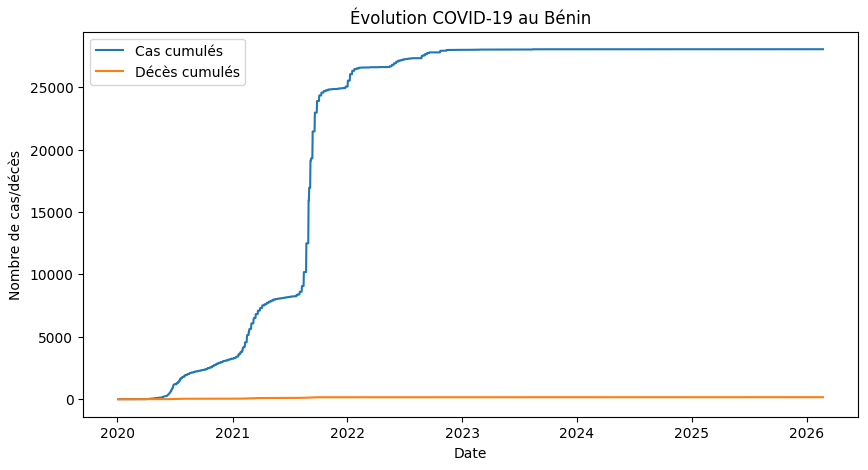

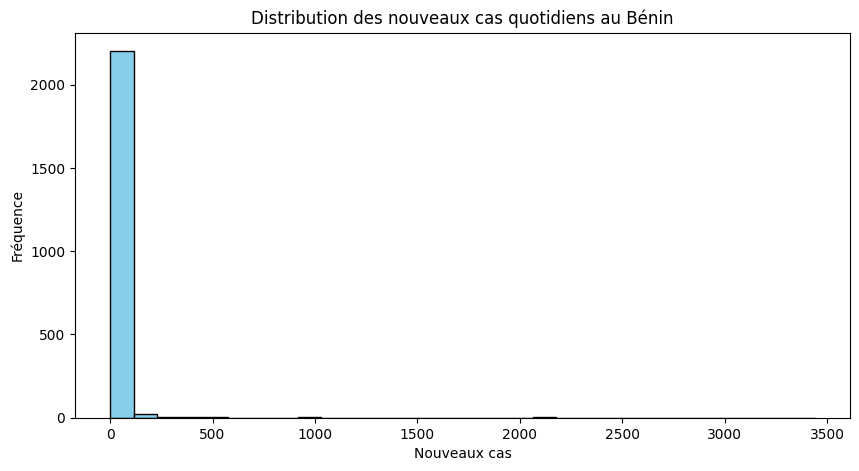

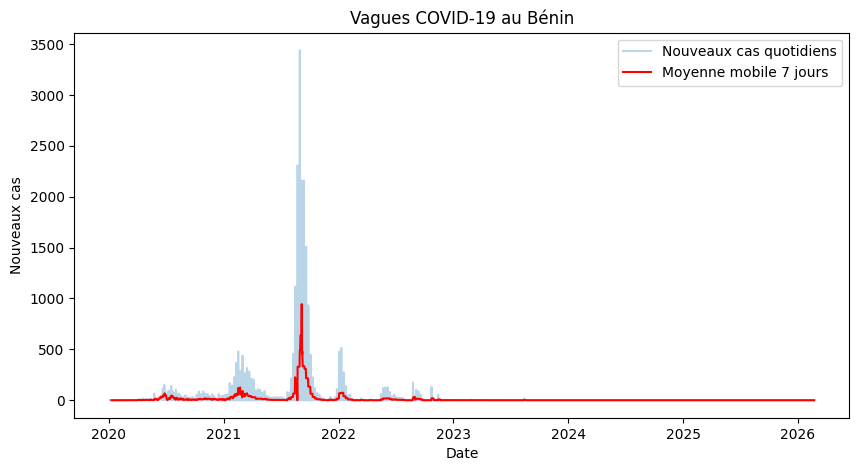

Anomalies détectées :

             date  new_cases
54258 2021-02-03      226.0
54265 2021-02-10      367.0
54271 2021-02-16      479.0
54277 2021-02-22      291.0
54285 2021-03-02      437.0
54292 2021-03-09      267.0
54299 2021-03-16      317.0
54306 2021-03-23      282.0
54439 2021-08-03      214.0
54446 2021-08-10      457.0
54452 2021-08-16     1118.0
54460 2021-08-24     2309.0
54467 2021-08-31     3440.0
54469 2021-09-02     1014.0
54473 2021-09-06     2160.0
54480 2021-09-13     2160.0
54487 2021-09-20     1508.0
54494 2021-09-27      932.0
54501 2021-10-04      445.0
54508 2021-10-11      225.0
54592 2022-01-03      478.0
54599 2022-01-10      514.0
54606 2022-01-17      273.0
        country       date  total_cases  new_cases  new_cases_smoothed  \
56  Afghanistan 2020-02-26          1.0        1.0            0.142857   
57  Afghanistan 2020-02-27          1.0        0.0            0.142857   
58  Afghanistan 2020-02-28          1.0        0.0            0.142857   
59  Afgh

In [14]:
# ============================================================
# Étude épidémiologique COVID-19
# Cahier de charges : Analyse exploratoire + KPI épidémiologiques
# ============================================================

# 1. Import des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 2. Chargement des données
df = pd.read_csv("../data/owid-covid-data.csv")

# 3. Aperçu des données
print("Colonnes disponibles :", df.columns.tolist())
df.head()

# 4. Nettoyage de base
# Conversion des dates
df['date'] = pd.to_datetime(df['date'])
# Suppression des lignes sans pays
df = df.dropna(subset=['country'])

# Statistiques descriptives globales
# ============================================================
# A. Décrire les distributions
# ============================================================


print(df[['new_cases','new_deaths']].describe())

# Top 10 pays par cas cumulés
top_cases = df.groupby("country")['total_cases'].max().sort_values(ascending=False).head(10)
print("Top 10 pays par cas cumulés :\n", top_cases)

# Top 10 pays par décès cumulés
top_deaths = df.groupby("country")['total_deaths'].max().sort_values(ascending=False).head(10)
print("Top 10 pays par décès cumulés :\n", top_deaths)


# ============================================================
# B. Visualiser les tendances temporelles
# ============================================================
# 5. Exploration descriptive
# # Exemple : évolution des cas au Bénin

benin = df[df['country'] == 'Benin']

plt.figure(figsize=(10,5))
plt.plot(benin['date'], benin['total_cases'], label="Cas cumulés")
plt.plot(benin['date'], benin['total_deaths'], label="Décès cumulés")
plt.title("Évolution COVID-19 au Bénin")
plt.xlabel("Date")
plt.ylabel("Nombre de cas/décès")
plt.legend()
plt.show()

# Histogramme des nouveaux cas quotidiens
plt.figure(figsize=(10,5))
plt.hist(benin['new_cases'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution des nouveaux cas quotidiens au Bénin")
plt.xlabel("Nouveaux cas")
plt.ylabel("Fréquence")
plt.show()

# ============================================================
# C. Détection de patterns (vagues, anomalies)
# ============================================================

# Moyenne mobile 7 jours pour lisser les vagues
benin['new_cases_ma7'] = benin['new_cases'].rolling(7).mean()

plt.figure(figsize=(10,5))
plt.plot(benin['date'], benin['new_cases'], alpha=0.3, label="Nouveaux cas quotidiens")
plt.plot(benin['date'], benin['new_cases_ma7'], color='red', label="Moyenne mobile 7 jours")
plt.title("Vagues COVID-19 au Bénin")
plt.xlabel("Date")
plt.ylabel("Nouveaux cas")
plt.legend()
plt.show()

# Détection d'anomalies simples : jours avec valeurs négatives ou très élevées
anomalies = benin[(benin['new_cases'] < 0) | (benin['new_cases'] > benin['new_cases'].quantile(0.99))]
print("Anomalies détectées :\n\n", anomalies[['date','new_cases']])


# ============================================================
# D Calcul des KPI épidémiologiques COVID-19
# ============================================================


# 1. Calcul des KPI par ligne (quotidien, par pays)
df['incidence'] = (df['new_cases'] / df['population']) * 100000
df['mortality'] = (df['new_deaths'] / df['population']) * 100000
df['cfr'] = (df['total_deaths'] / df['total_cases']) * 100   # Case Fatality Rate
df['recovery_rate'] = ((df['total_cases'] - df['total_deaths']) / df['total_cases']) * 100
df['vaccination_rate'] = (df['people_fully_vaccinated'] / df['population']) * 100

# 2. Nettoyage des données abbérantes

# Remplacer les valeurs négatives par NaN
cols_to_clean = ['total_cases', 'total_deaths', 'recovery_rate']
for col in cols_to_clean:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)

#  Supprimer les lignes où total_cases est nul ou manquant
df = df[df['total_cases'].notna() & (df['total_cases'] > 0)]

#  Corriger les incohérences : décès > cas
df.loc[df['total_deaths'] > df['total_cases'], 'total_deaths'] = np.nan

#  Recalculer recovery_rate proprement
df['recovery_rate'] = (df['total_cases'] - df['total_deaths']) / df['total_cases'] * 100

#  Optionnel : supprimer les outliers extrêmes du recovery_rate
# (par exemple, en gardant uniquement les valeurs entre 0 et 100 %)
df.loc[(df['recovery_rate'] < 0) | (df['recovery_rate'] > 100), 'recovery_rate'] = np.nan

# Vérification
print(df.head())

# 3. Calcul des KPI épidémiologiques COVID-19 par pays (hybride mean/median)

kpi_global = df.groupby("country").agg({
    'population':'max',            # population reste fixe
    'total_cases':'max',           # cumul final
    'total_deaths':'max',          # cumul final
    'incidence':'median',          # médiane pour neutraliser les anomalies
    'mortality':'max',             # cumul final
    'cfr':'median',                # médiane pour neutraliser les anomalies
    'recovery_rate':'mean',         # cumul final
    'vaccination_rate':'mean'      # moyenne pour refléter la tendance globale
}).reset_index()


# 4. Export vers CSV
kpi_global.to_csv("../data/covid_kpi_global.csv", index=False)

print("\n\n✅ Fichier exporté : data/covid_kpi_global.csv")
print(kpi_global.head())
